<a href="https://colab.research.google.com/github/glee25/Stock-Prediction-glee25/blob/main/StockPrice(GOOG)_ARIMA%26LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
!pip install pmdarima
!pip install tensorflow
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from pmdarima.arima import auto_arima

In [13]:
# Load data
df = pd.read_csv('/content/GOOG.csv', parse_dates=['Date'])
df = df[['Date', 'Close']]
df.set_index('Date', inplace=True)

# Split data (keep raw copies for ARIMA)
split_idx = int(len(df) * 0.8)
train_raw = df.iloc[:split_idx]
test_raw  = df.iloc[split_idx:]

# Scale data
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_raw)
test_scaled  = scaler.transform(test_raw)

# Include last seq_length rows of train when building test sequences
overlap          = train_scaled[-60:]
test_scaled_full = np.concatenate([overlap, test_scaled], axis=0)

# Create sequences
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(seq_length, len(data)):
        X.append(data[i - seq_length:i])
        y.append(data[i])
    return np.array(X), np.array(y)

seq_length = 60
X_train, y_train = create_sequences(train_scaled, seq_length)
X_test,  y_test  = create_sequences(test_scaled_full, seq_length)

# Build & train LSTM
model_lstm = Sequential([
    LSTM(50, return_sequences=True, input_shape=(seq_length, 1)),
    Dropout(0.2),
    LSTM(50, return_sequences=True),
    Dropout(0.2),
    LSTM(50, return_sequences=True),
    Dropout(0.2),
    LSTM(50),
    Dropout(0.2),
    Dense(1)
])
model_lstm.compile(optimizer='adam', loss='mean_squared_error')

es = EarlyStopping(monitor='val_loss', mode='min', patience=5, verbose=1)
model_lstm.fit(X_train, y_train,
               validation_data=(X_test, y_test),
               epochs=100, batch_size=32, callbacks=[es])

# Predictions + inverse transform
train_pred_lstm = scaler.inverse_transform(model_lstm.predict(X_train))
test_pred_lstm  = scaler.inverse_transform(model_lstm.predict(X_test))
y_train_actual  = scaler.inverse_transform(y_train)
y_test_actual   = scaler.inverse_transform(y_test)

# FIX 1: Pass a RangeIndex series to ARIMA to avoid datetime index loss
# Stock data has irregular gaps (weekends/holidays) so DatetimeIndex has
# no inferable frequency — ARIMA drops it and returns an integer index.
# Using reset_index gives it a clean 0..n RangeIndex instead.
model_arima = auto_arima(train_raw['Close'].reset_index(drop=True),
                         seasonal=False, stepwise=True, suppress_warnings=True)

# FIX 2: Wrap predict() in np.array() so assignment into the DataFrame
# uses positional values, not index alignment
arima_pred_array = np.array(model_arima.predict(n_periods=len(test_raw)))

# Build combined_pred with consistent, aligned index
n = len(test_pred_lstm)
test_index_aligned = test_raw.index[-n:]

combined_pred = pd.DataFrame({
    'Actual':   test_raw['Close'].values[-n:],
    'LSTM':     test_pred_lstm.flatten(),
    'ARIMA':    arima_pred_array[-n:],
    'Combined': (test_pred_lstm.flatten() + arima_pred_array[-n:]) / 2
}, index=test_index_aligned)

print(combined_pred.isnull().sum())
assert combined_pred.isnull().sum().sum() == 0, "NaNs remain — check lengths"

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 33s 148ms/step - loss: 0.0132 - val_loss: 0.0352
Epoch 2/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 14s 139ms/step - loss: 0.0023 - val_loss: 0.0396
Epoch 3/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 15s 145ms/step - loss: 0.0023 - val_loss: 0.0567
Epoch 4/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 14s 139ms/step - loss: 0.0020 - val_loss: 0.0574
Epoch 5/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 21s 141ms/step - loss: 0.0019 - val_loss: 0.0157
Epoch 6/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 22s 154ms/step - loss: 0.0018 - val_loss: 0.0403
Epoch 7/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 19s 139ms/step - loss: 0.0017 - val_loss: 0.0286
Epoch 8/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 14s 139ms/step - loss: 0.0015 - val_loss: 0.0153
Epoch 9/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 20s 137ms/step - loss: 0.0014 - val_loss: 0.0269
Epoch 10/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 21s 137ms/step - loss: 0.0014 - val_loss: 0.0222
Epoch 11/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 15s 143ms/step - loss: 0.0016 - val_loss: 0.0147
Epoch 12

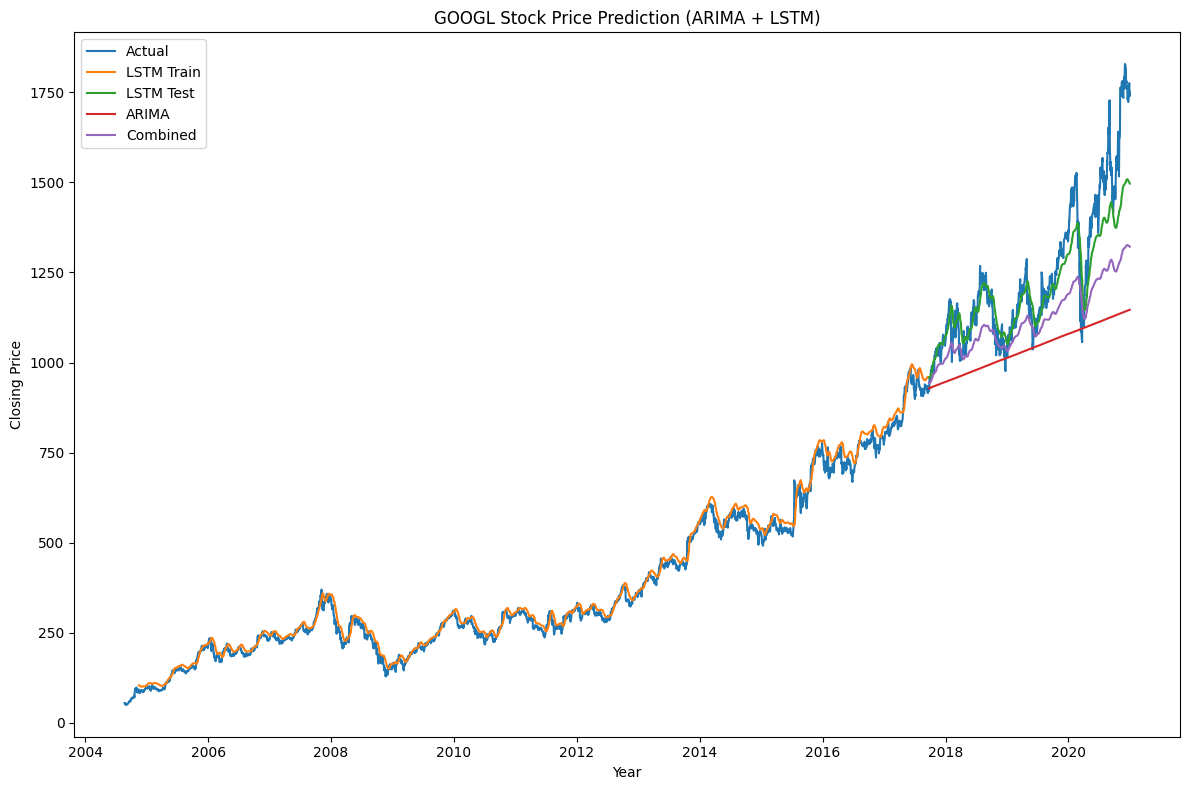

In [16]:
# Plot
plt.figure(figsize=(12, 8))
plt.plot(df['Close'],              label='Actual', linewidth=1.5)
plt.plot(train_index, train_pred_lstm, label='LSTM Train')
plt.plot(combined_pred['LSTM'],    label='LSTM Test')
plt.plot(combined_pred['ARIMA'],   label='ARIMA')
plt.plot(combined_pred['Combined'],label='Combined')
plt.title('GOOGL Stock Price Prediction (ARIMA + LSTM)')
plt.xlabel('Year')
plt.ylabel('Closing Price')
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
# Evaluation with consistent shapes
actual = combined_pred['Actual'].values
for name in ['LSTM', 'ARIMA', 'Combined']:
    pred = combined_pred[name].values
    mse  = mean_squared_error(actual, pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(actual, pred)
    mape = np.mean(np.abs((actual - pred) / actual)) * 100
    print(f"\n--- {name} ---")
    print(f"MSE:  {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"MAPE: {mape:.2f}%")


--- LSTM ---
MSE:  9001.2336
RMSE: 94.8748
MAE:  64.7241
MAPE: 4.73%

--- ARIMA ---
MSE:  64793.6585
RMSE: 254.5460
MAE:  204.0216
MAPE: 15.10%

--- Combined ---
MSE:  28260.2458
RMSE: 168.1078
MAE:  124.1208
MAPE: 8.98%
